In [2]:
%pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    --------------------------------------- 0.8/37.3 MB 4.1 MB/s eta 0:00:09
   - -------------------------------------- 1.8/37.3 MB 4.8 MB/s eta 0:00:08
   --- ------------------------------------ 2.9/37.3 MB 4.7 MB/s eta 0:00:08
   ---- ----------------------------------- 3.9/37.3 MB 4.8 MB/s eta 0:00:07
   ---- ----------------------------------- 4.5/37.3 MB 4.3 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/37.3 MB 4.3 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/37.3 MB 4.3 MB/s eta 0:00:08
   ----- ---------------------------------- 5.0/37.3 MB 2.9 MB/s eta 0:00:12
   ----- ---------------------------------- 5.2/37.3 MB 2.9 MB/s eta 0:00:12
   ------ --------------------------------- 5.8/37.3 MB 2.8 MB/s eta 0:00:12
   ------ --------------------------------- 6.3/37.3 MB 2.8 MB/s eta 0:00:12
   ------- -------------------------------- 6.6/37.3 MB 2.8 MB/s eta 0:00:12
   ---


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 5.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.3 MB 3.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 5.6 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.6 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("../data/cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Descriptive Statistical Analysis

Descriptive statistics are used to understand the central tendency, spread, and distribution of the Superstore dataset.

In [6]:
# Select numerical columns
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Descriptive statistics
stats_summary = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Standard Deviation': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew()
})

stats_summary

,Mean,Median,Mode,Standard Deviation,Skewness
Sales,229.858001,54.4900,12.96,623.245101,12.972752
Quantity,3.789574,3.0000,3.00,2.225110,1.278545
Discount,0.156203,0.2000,0.00,0.206452,1.684295
Profit,28.656896,8.6665,0.00,234.260108,7.561432


In [7]:
df[numeric_cols].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Hypothesis Testing

A two-sample t-test is performed to determine whether the average profit differs significantly between the Consumer and Corporate customer segments.

**Null Hypothesis (H₀):** The mean profit of Consumer and Corporate segments is equal.

**Alternative Hypothesis (H₁):** The mean profit of Consumer and Corporate segments is different.

Significance level (α) = 0.05

In [8]:
# Select profit for Consumer and Corporate segments
consumer_profit = df[df['Segment'] == 'Consumer']['Profit'].dropna()
corporate_profit = df[df['Segment'] == 'Corporate']['Profit'].dropna()

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    consumer_profit,
    corporate_profit,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean profit.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean profit.")

T-statistic: -0.8555511671728538
P-value: 0.3922774231363087
Fail to reject the null hypothesis.
There is no statistically significant difference in mean profit.


## 3. Confidence Interval

A 95% confidence interval is calculated to estimate the range in which the true mean profit is likely to fall.

In [9]:
# Calculate 95% confidence interval for mean profit

profit = df['Profit'].dropna()

mean_profit = profit.mean()
std_profit = profit.std()
n = len(profit)

# Standard error
standard_error = std_profit / np.sqrt(n)

# 95% confidence interval
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean_profit,
    scale=standard_error
)

print("Mean Profit:", mean_profit)
print("95% Confidence Interval:")
print("Lower Bound:", confidence_interval[0])
print("Upper Bound:", confidence_interval[1])

Mean Profit: 28.65689630778467
95% Confidence Interval:
Lower Bound: 24.063548171678743
Upper Bound: 33.250244443890594


## 4. Time Series Analysis

The Order Date column is converted into a time-series format.
Monthly sales are calculated to identify trends over time.

In [10]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check the data type
print(df['Order Date'].dtype)

datetime64[us]


In [11]:
# Set Order Date as the index
monthly_sales = df.set_index('Order Date')['Sales'].resample('ME').sum()

# Display monthly sales
monthly_sales.head(10)

Order Date
2014-01-31    14236.8950
2014-02-28     4519.8920
2014-03-31    55691.0090
2014-04-30    28295.3450
2014-05-31    23648.2870
2014-06-30    34595.1276
2014-07-31    33946.3930
2014-08-31    27909.4685
2014-09-30    81777.3508
2014-10-31    31453.3930
Freq: ME, Name: Sales, dtype: float64

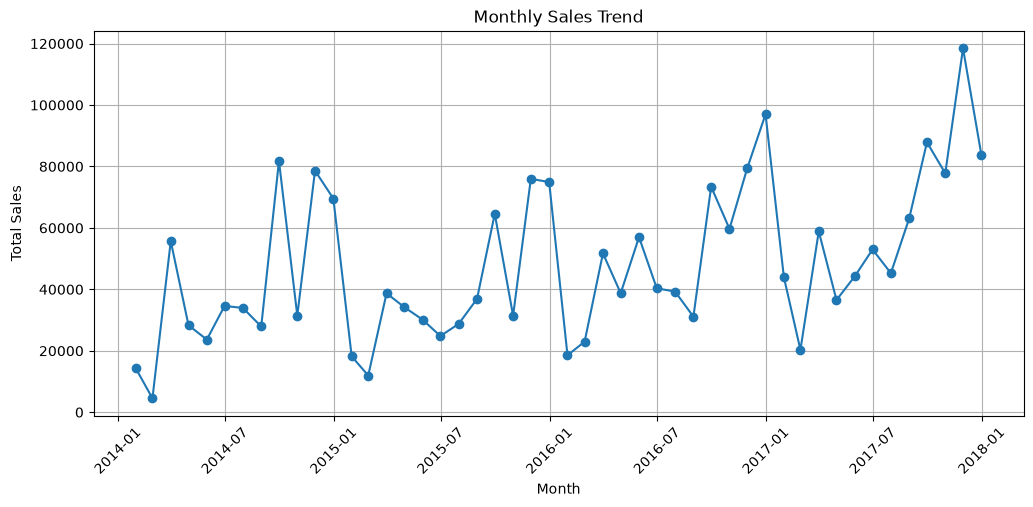

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [13]:
# Calculate 3-month moving average
moving_average = monthly_sales.rolling(window=3).mean()

# Display the results
moving_average.tail(10)

Order Date
2017-03-31    41048.286733
2017-04-30    38565.007433
2017-05-31    46551.666367
2017-06-30    44588.124000
2017-07-31    47502.417300
2017-08-31    53789.009900
2017-09-30    65417.318667
2017-10-31    76254.821067
2017-11-30    94697.133400
2017-12-31    93351.355667
Freq: ME, Name: Sales, dtype: float64

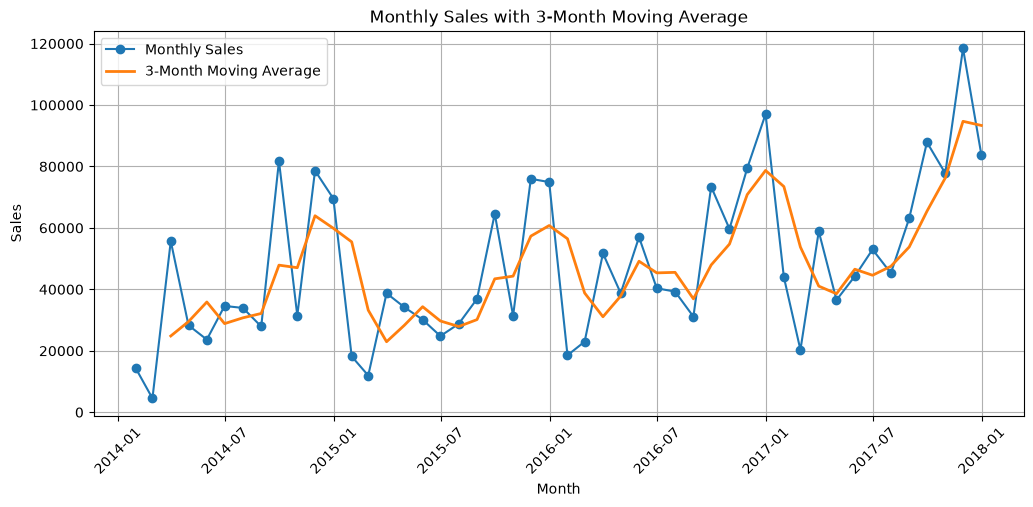

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    label='Monthly Sales'
)

plt.plot(
    moving_average.index,
    moving_average.values,
    linewidth=2,
    label='3-Month Moving Average'
)

plt.title('Monthly Sales with 3-Month Moving Average')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## 5. Customer Segmentation using K-Means

Customers are segmented based on their purchasing behavior using Recency, Frequency, and Monetary features.

The features are standardized before applying K-Means clustering.

In [15]:
# Set the reference date as the latest order date
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Create customer-level RFM features
customer_data = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

# Display customer data
customer_data.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [16]:
print("Number of customers:", len(customer_data))

customer_data.describe()

Number of customers: 793


,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,147.802018,6.316520,2896.848500
std,186.211051,2.550885,2628.670117
min,1.000000,1.000000,4.833000
25%,31.000000,5.000000,1146.050000
50%,76.000000,6.000000,2256.394000
75%,184.000000,8.000000,3785.276000
max,1166.000000,17.000000,25043.050000


In [17]:
# Select features for clustering
features = ['Recency', 'Frequency', 'Monetary']

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_data[features])

print("Features standardized successfully.")

Features standardized successfully.


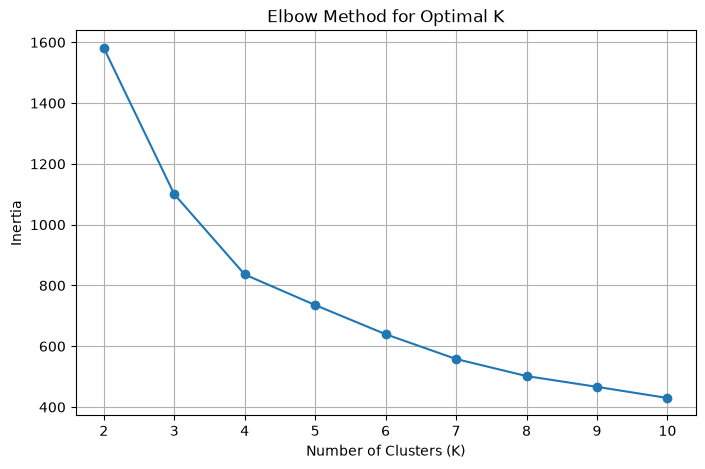

In [18]:
# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [19]:
# Apply K-Means clustering with 4 clusters
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

# Display the first few customers with their cluster
customer_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,185,5,5563.560,1
1,AA-10375,20,9,1056.390,0
2,AA-10480,260,4,1790.512,1
3,AA-10645,56,6,5086.935,0
4,AB-10015,416,3,886.156,3


In [20]:
customer_data['Cluster'].value_counts().sort_index()

Cluster
0    298
1    335
2     64
3     96
Name: count, dtype: int64

## 6. PCA Visualization of Customer Segments

Principal Component Analysis (PCA) is used to reduce the three standardized customer features into two dimensions for visualizing the K-Means clusters.

In [21]:
# Apply PCA to reduce the features to 2 dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

# Add PCA coordinates to customer data
customer_data['PCA1'] = pca_features[:, 0]
customer_data['PCA2'] = pca_features[:, 1]

# Display the PCA data
customer_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,PCA1,PCA2
0,AA-10315,185,5,5563.560,1,0.107654,0.817770
1,AA-10375,20,9,1056.390,0,0.669432,-0.953745
2,AA-10480,260,4,1790.512,1,-1.141406,0.141207
3,AA-10645,56,6,5086.935,0,0.626025,0.192287
4,AB-10015,416,3,886.156,3,-2.020707,0.520728


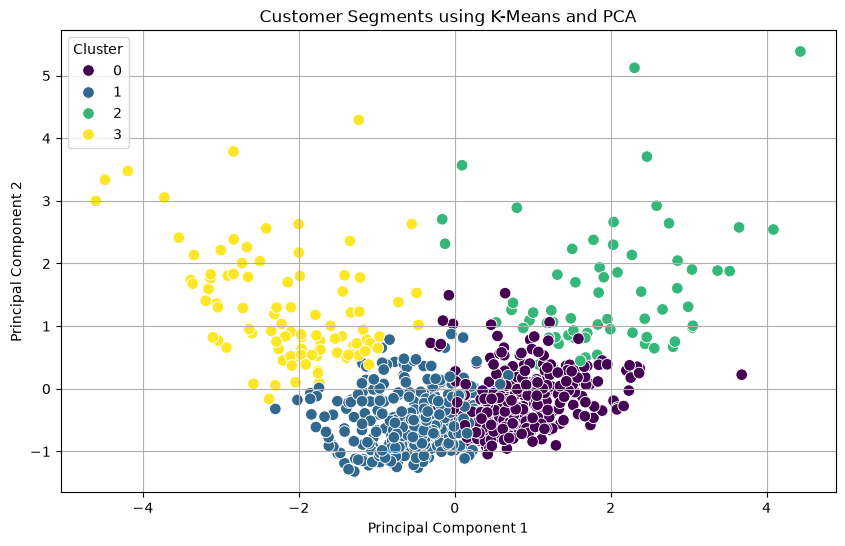

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segments using K-Means and PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.show()

In [23]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.54766481 0.28598897]
Total variance explained: 0.8336537772968742


## 7. Customer Segment Profiling

The average Recency, Frequency, and Monetary values are calculated for each customer cluster to understand the characteristics of each segment.

In [24]:
# Calculate average RFM values for each cluster
cluster_profile = customer_data.groupby('Cluster')[features].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,72.74,8.52,3322.22
1,101.20,4.73,1669.69
2,123.72,8.30,9479.55
3,559.49,3.70,1470.23


## 8. Basic Predictive Model - Linear Regression

A Linear Regression model is developed to predict Sales using selected numerical features from the Superstore dataset.

The dataset is divided into 80% training data and 20% testing data.

In [27]:
# Select features and target
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7995
Testing samples: 1999


In [28]:
# Create and train the model
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [29]:
# Predict sales on the test data
y_pred = model.predict(X_test)

# Display some predictions
comparison = pd.DataFrame({
    'Actual Sales': y_test.values[:10],
    'Predicted Sales': y_pred[:10]
})

comparison

,Actual Sales,Predicted Sales
0,563.808,231.036433
1,36.672,132.814532
2,37.300,91.798593
3,212.058,157.770522
4,171.288,146.436917
5,99.136,211.564861
6,340.182,91.277496
7,17.380,78.574340
8,22.620,216.153603
9,71.632,516.836576


In [30]:
# Calculate evaluation metrics

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation Results")
print("------------------------")
print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

Model Evaluation Results
------------------------
R² Score: -0.1518
MAE: 245.08
RMSE: 824.85


In [31]:
# Feature importance based on Linear Regression coefficients

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance['Absolute Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
1,Discount,249.571780,249.571780
0,Quantity,41.550264,41.550264
2,Profit,1.561674,1.561674


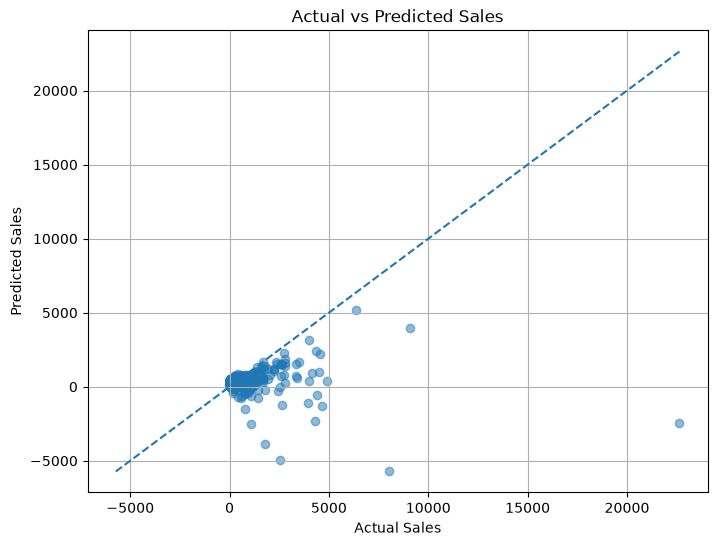

In [32]:
# Plot Actual vs Predicted Sales

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

# Reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.grid(True)
plt.show()

In [33]:
# Save customer segmentation results
customer_data.to_csv(
    "../data/customer_segments.csv",
    index=False
)

print("Customer segmentation results saved successfully.")

Customer segmentation results saved successfully.


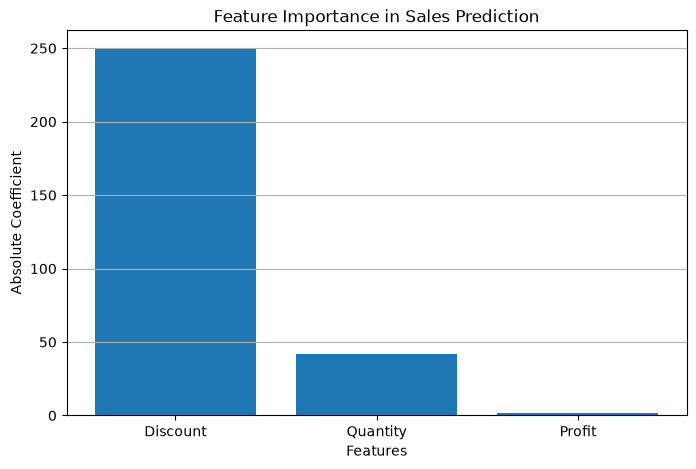

In [34]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Absolute Coefficient']
)

plt.title('Feature Importance in Sales Prediction')
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient')

plt.grid(axis='y')
plt.show()

### Model Findings

The Linear Regression model was evaluated using R², MAE, and RMSE.
The feature coefficients were analyzed to identify the relative importance of Quantity, Discount, and Profit in predicting Sales.

In [35]:
print("Model Evaluation Results")
print("------------------------")
print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

Model Evaluation Results
------------------------
R² Score: -0.1518
MAE: 245.08
RMSE: 824.85


## 9. Conclusion and Business Recommendations

### Key Findings

1. Descriptive statistical analysis was performed on Sales, Quantity, Discount, and Profit.
2. A two-sample t-test was performed to compare the average Profit between Consumer and Corporate segments.
3. A 95% confidence interval was calculated for the mean Profit.
4. Monthly sales trends and a 3-month moving average were analyzed to understand sales patterns over time.
5. K-Means clustering divided customers into 4 segments based on Recency, Frequency, and Monetary values.
6. PCA reduced the customer features to two dimensions, explaining approximately 83.37% of the total variance.
7. A Linear Regression model was developed to predict Sales using Quantity, Discount, and Profit.
8. The model was evaluated using R², MAE, and RMSE.

### Business Recommendations

1. Focus marketing campaigns on high-value customer segments identified through RFM analysis.
2. Develop retention strategies for customers with higher recency values to encourage repeat purchases.
3. Use sales trends and moving averages to support inventory and sales planning.
4. Use customer segmentation to provide more targeted offers and improve customer engagement.
5. Monitor the prediction model's performance and update it with new sales data over time.

### Overall Conclusion

Task 4 applied statistical analysis, time-series analysis, customer segmentation, and predictive modeling to the Superstore dataset. The analysis provides insights into customer purchasing behavior, sales trends, customer segments, and sales prediction.